# Credit Card Fraud Detection

Goal: flag fraudulent transactions in a highly imbalanced dataset.

- 284,807 transactions, only 492 are fraud (~0.17%)
- Features V1–V28 are PCA components (already anonymized), plus Time and Amount
- Because fraud is so rare, accuracy is a useless metric here — precision, recall, and F1 matter more

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

df = pd.read_csv('data/creditcard.csv')
df.shape

(284807, 31)

## Quick look at the imbalance

This is the whole problem in one chart. If a model just predicted "not fraud" every time, it would be 99.83% accurate and completely useless.

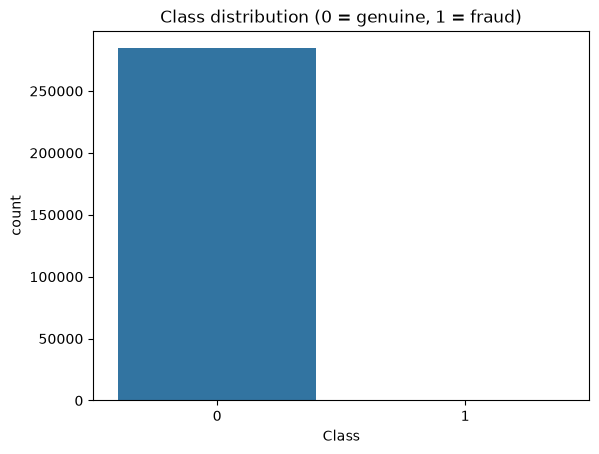

In [2]:
df['Class'].value_counts()
sns.countplot(x='Class', data=df)
plt.title('Class distribution (0 = genuine, 1 = fraud)')
plt.show()

## Scaling Time and Amount

V1–V28 are already PCA-transformed, so they're on a similar scale. Time and Amount aren't — they need scaling before going into a model that's sensitive to magnitude (like logistic regression).

In [3]:
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Time', 'Amount'], axis=1)

## Train-test split

Splitting before touching the imbalance. Using `stratify=y` so both train and test sets keep the same fraud ratio — otherwise a random split could leave the test set with almost no fraud cases.

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Handling the imbalance

Two common approaches:
1. **Undersampling** — randomly drop genuine transactions until classes are balanced. Fast, but throws away a lot of data.
2. **Oversampling (SMOTE)** — synthetically generate more fraud examples. Keeps all the data, usually performs better.

Going with SMOTE, applied only to the training set — never touch the test set, or the evaluation becomes meaningless.

In [5]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

y_train_res.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

## Baseline model: Logistic Regression

Starting simple to get a benchmark before trying something heavier.

In [6]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698482164390798


## Random Forest

Trying an ensemble model — usually stronger on this kind of tabular, non-linear pattern.

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9688299436966684


## Confusion matrix — Random Forest

Precision and recall numbers are useful, but seeing the actual counts of false positives vs false negatives makes the tradeoff concrete. In fraud detection, a false negative (missed fraud) is usually far more costly than a false positive (flagging a genuine transaction).

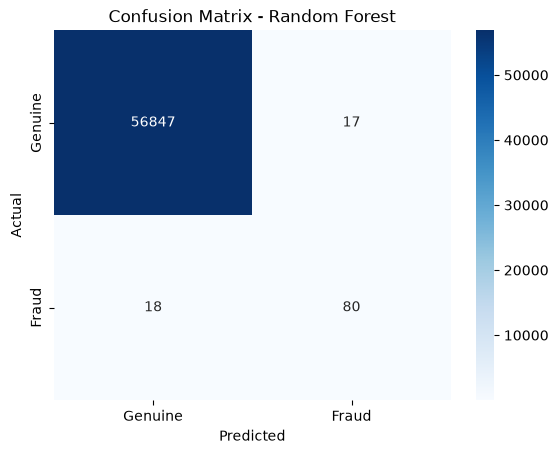

In [8]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

## Wrap-up

- Logistic Regression (with SMOTE) gives a fast, interpretable baseline
- Random Forest used `class_weight='balanced'` instead of SMOTE — trains on the original data, faster, and lets the trees handle the imbalance natively
- SMOTE on the training set only (never the test set) keeps evaluation honest
- Next: this is the model that'll back the Streamlit demo app